# Project: TPU Cable Clip

Flexible cable organizer clip designed for TPU filament. Three snap-in cable channels
(3 mm, 4 mm, 6 mm) use TPU's flexibility to hold cables securely. Cables push through
a narrow snap slot into the round channel. Prints flat, no supports, ~10 min print.

## 1. The need

Quick, functional desk accessory to tidy cables. Must:
- Print on FDM in TPU (yellow or green available)
- Be small and fast to print
- Use TPU flexibility as a feature (snap-in cable retention)
- Need zero supports

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parents[1] / 'src'))
from agentic_cad.runner import run
from agentic_cad.study import run_study
from agentic_cad.nb import show_run, show_annotations

PROFILE = Path.cwd().parents[1] / 'profiles' / 'elegoo_cc2_pla.json'
MODEL = Path.cwd() / 'model.py'
OUT = Path.cwd() / 'outputs'

## 2. Build and verify

Using the PLA profile for gate verification (geometry is material-agnostic).
Slice with TPU settings in the slicer manually for the actual print.

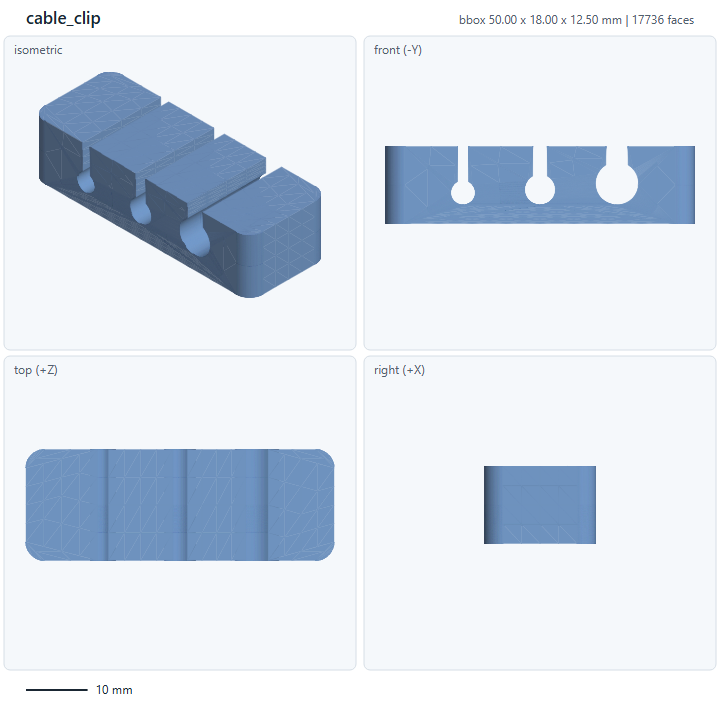

In [2]:
report_path, report = run(MODEL, PROFILE, OUT, enable_slicer=False, enable_freecad=False, enable_raster=True)
show_run(report)

## 3. Annotate

Pin comments on the renders to adjust groove sizes, snap tightness, etc.

In [3]:
# pins = show_annotations(Path.cwd() / 'annotations.json')

## 4. Parameter sweep (optional)

Try different snap ratios to find the right cable retention vs. ease of insertion.

In [4]:
# _, study = run_study(MODEL, PROFILE, OUT / 'studies',
#     {'snap_ratio': [0.50, 0.60, 0.70]}, minimize='total_volume_mm3')
# print(study['recommended'])

## 5. Release

Full gates. For actual printing, load the STL in your slicer with TPU presets
(15-25 mm/s, 220-235 C nozzle, 50-60 C bed, 2-3 wall loops).

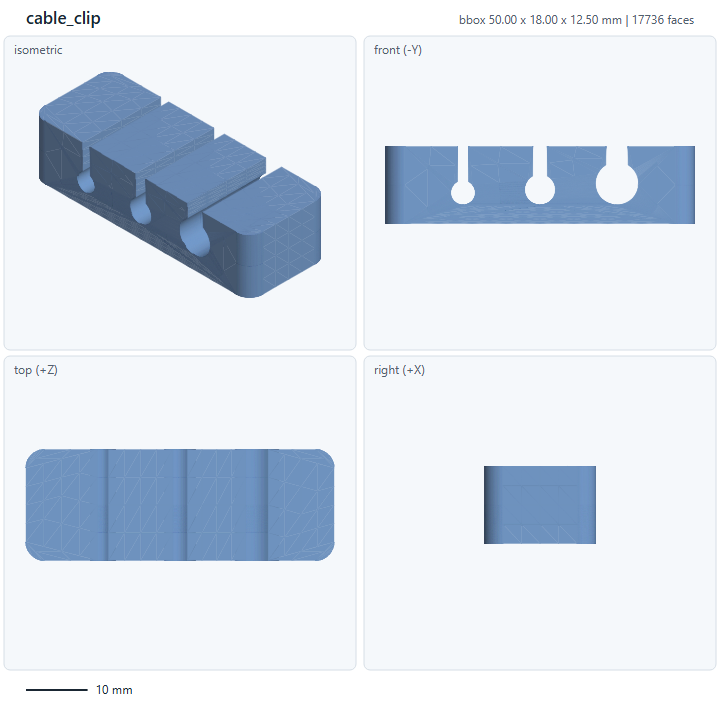

cable_clip | STL: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\tpu-cable-clip\outputs\tpu_cable_clip\cable_clip.stl | slicer: C:\Users\srilu\Documents\Codex\2026-07-20\i\work\agentic-3d-modeling\experiments\tpu-cable-clip\outputs\tpu_cable_clip\slicer\cable_clip\plate_1.gcode


In [5]:
report_path, report = run(MODEL, PROFILE, OUT, enable_raster=True)
show_run(report)
for part in report['parts']:
    print(part['name'], '| STL:', part['artifacts']['stl'],
          '| slicer:', part['slicer'].get('gcode', part['slicer']['status']))